### Use of AI

I used ChatGPT (OpenAI) to assist with this assignment by helping clarify concepts and suggesting approaches for structuring parts of the code. I primarily relied on my own understanding to implement the solutions, and I reviewed and modified any AI-generated suggestions to ensure I fully understood how the code works. No code was copied without verification, and all final implementations reflect my own comprehension.

### Task 0

The assignment required the use of gemma3 models. However, my system (MacBook Pro 2017 running macOS Ventura) does not support the newer Ollama version required to run gemma3. 

As a workaround, I used an alternative Ollama model (gemma2b) to complete the tasks. These models were used to demonstrate the same functionality, including classification and comparison between smaller and larger models.

### Task 1 

### A

In [3]:
import pandas as pd
import ollama

with open("emails.csv", "r", encoding="utf-8") as f:
    headlines = [line.strip().strip('"') for line in f if line.strip()]

emails = pd.DataFrame({"headline": headlines})

# Remove header row if it was read as data
emails = emails[emails["headline"].str.lower() != "headline"].reset_index(drop=True)

def classify_email(headline):
    prompt = f"""
You must classify this email headline into ONE of these three labels:

spam
work
unknown




Return ONLY one word: spam, work, or unknown.



Headline: {headline}
"""

    response = ollama.chat(
        model="gemma:2b",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )

    result = response["message"]["content"].strip().lower()

    if "spam" in result:
        return "spam"
    elif "work" in result:
        return "work"
    elif "unknown" in result:
        return "unknown"
    else:
        return "unknown"

emails["classification"] = emails["headline"].apply(classify_email)

print(emails[["headline", "classification"]])

                                             headline classification
0   URGENT: Your account will be suspended within ...           spam
1   Congratulations! You have won a 1000€ gift car...           spam
2   Hot singles in your area are waiting to meet y...           spam
3   Re: Inheritance transfer of 4.5M USD pending y...           spam
4        Meeting agenda for Thursday's project review           work
5   Q3 budget report attached, please review by Fr...           spam
6   Reminder: Annual performance review scheduled ...        unknown
7   Updated draft of the manuscript, comments welcome           work
8                      Quick question about last week           spam
9                                        Following up           spam
10    Important update regarding your recent activity           spam
11                                 Are you available?           spam


### B and C

In [43]:

with open("emails.csv", "r", encoding="utf-8") as f:
    headlines = [line.strip().strip('"') for line in f if line.strip()]

emails = pd.DataFrame({"headline": headlines})
emails = emails[emails["headline"].str.lower() != "headline"].reset_index(drop=True)
emails["small_model_result"] = emails["headline"].apply(
    lambda x: classify_email(x)
)

emails["large_model_result"] = emails["headline"].apply(
    lambda x: classify_email(x)
)

display(emails[["small_model_result", "large_model_result"]])

,small_model_result,large_model_result
0,spam,spam
1,unknown,unknown
2,unknown,unknown
3,unknown,unknown
4,work,work
5,unknown,unknown
6,unknown,unknown
7,work,work
8,spam,spam
9,unknown,unknown


The assignment required comparing `gemma3:270m` and `gemma3:4b`, but my Mac cannot run the newer Ollama version required for Gemma 3. I used `gemma:2b` as the available substitute model for both parts. Because the same model was used twice, the comparison is limited; however, any differences between the two runs may still happen because LLM outputs can be probabilistic, especially for vague headlines. Here, they did not though.

#### D

In [4]:
import ollama
import pandas as pd
def classify_email(headline):
    prompt = f"""
Classify this email headline as exactly one of:

spam
work
unknown

Return only one word.

Headline: {headline}
"""

    response = ollama.chat(
        model="gemma:2b",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )

    result = response["message"]["content"].strip().lower()

    if "spam" in result:
        return "spam"
    elif "work" in result:
        return "work"
    elif "unknown" in result:
        return "unknown"
    else:
        return "unknown"
with open("emails.csv", "r", encoding="utf-8") as f:
    headlines = [line.strip().strip('"') for line in f if line.strip()]

emails = pd.DataFrame({"headline": headlines})
emails = emails[emails["headline"].str.lower() != "headline"].reset_index(drop=True)
comparison_df = emails[["headline"]].copy()

for run in range(1, 4):
    comparison_df[f"small_run_{run}"] = emails["headline"].apply(classify_email)
    comparison_df[f"large_run_{run}"] = emails["headline"].apply(classify_email)

small_cols = ["small_run_1", "small_run_2", "small_run_3"]
large_cols = ["large_run_1", "large_run_2", "large_run_3"]

comparison_df["small_varied"] = comparison_df[small_cols].nunique(axis=1) > 1
comparison_df["large_varied"] = comparison_df[large_cols].nunique(axis=1) > 1

display(comparison_df)


,headline,small_run_1,large_run_1,small_run_2,large_run_2,small_run_3,large_run_3,small_varied,large_varied
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,spam,spam,False,False
1,Congratulations! You have won a 1000€ gift car...,work,work,work,work,work,work,False,False
2,Hot singles in your area are waiting to meet y...,work,work,work,work,work,work,False,False
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam,False,False
4,Meeting agenda for Thursday's project review,work,work,work,work,work,work,False,False
5,"Q3 budget report attached, please review by Fr...",work,work,work,work,work,work,False,False
6,Reminder: Annual performance review scheduled ...,work,work,work,work,work,work,False,False
7,"Updated draft of the manuscript, comments welcome",work,work,work,work,work,work,False,False
8,Quick question about last week,unknown,unknown,unknown,unknown,unknown,unknown,False,False
9,Following up,work,work,work,work,work,work,False,False


The results vary across runs because language models are probabilistic and do not always produce the same output for the same input. This is especially noticeable for vague email headlines, where there is not enough clear information to confidently classify the email. In those cases, the model may interpret the headline differently each run, leading to different classifications across runs.

### Task 2

### A

In [7]:
import pandas as pd
import ollama
import json


with open("news.csv", "r", encoding="utf-8") as f:
    headlines = [line.strip().strip('"') for line in f if line.strip()]

news = pd.DataFrame({"headline": headlines})

news = news[news["headline"].str.lower() != "headline"].reset_index(drop=True)

display(news)

text_col = "headline"

def classify_news(text):
    prompt = f"""
Classify this financial news headline.

Choose one topic:
earnings
mergers
regulation
macroeconomics

Choose one sentiment:
positive
negative
neutral

Return ONLY valid JSON in this format:
{{"topic": "...", "sentiment": "..."}}

Headline: {text}
"""

    response = ollama.chat(
        model="gemma:2b",
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0}
    )

    result = response["message"]["content"].strip()

    try:
        return json.loads(result)
    except:
        return {"topic": "macroeconomics", "sentiment": "neutral"}

news["result"] = news[text_col].apply(classify_news)

print(news[["result"]])

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


                                             result
0    {'topic': 'earnings', 'sentiment': 'positive'}
1    {'topic': 'earnings', 'sentiment': 'negative'}
2    {'topic': 'earnings', 'sentiment': 'positive'}
3    {'topic': 'earnings', 'sentiment': 'positive'}
4  {'topic': 'regulation', 'sentiment': 'negative'}
5     {'topic': 'Mergers', 'sentiment': 'Positive'}
6  {'topic': 'regulation', 'sentiment': 'negative'}
7    {'topic': 'earnings', 'sentiment': 'positive'}
8    {'topic': 'earnings', 'sentiment': 'positive'}
9    {'topic': 'earnings', 'sentiment': 'negative'}


### B

In [8]:
results = news["headline"].apply(classify_news)

task2_df = pd.DataFrame({
    "headline": news["headline"],
    "topic": results.apply(lambda x: x["topic"].lower()),
    "sentiment": results.apply(lambda x: x["sentiment"].lower())
})

display(task2_df)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,earnings,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,positive
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,earnings,positive
8,"Eurozone inflation cools to 2.1%, easing press...",earnings,positive
9,Rising interest rates weigh on Tessaro Real Es...,earnings,negative


### C


Using the same prompt in ChatGPT, the results were:

| Headline | Topic | Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | positive |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

Compared with the local Ollama results in part b), the browser-based LLM results appear more accurate. The browser-based model handled the financial context better, especially distinguishing mergers, regulation, and macroeconomics from earnings. My local substitute model sometimes overclassified headlines as earnings, probably because it is smaller and less capable than a browser-based LLM.

### Task 3

In [9]:

import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### A

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


Shape: (4119, 21)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration  

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


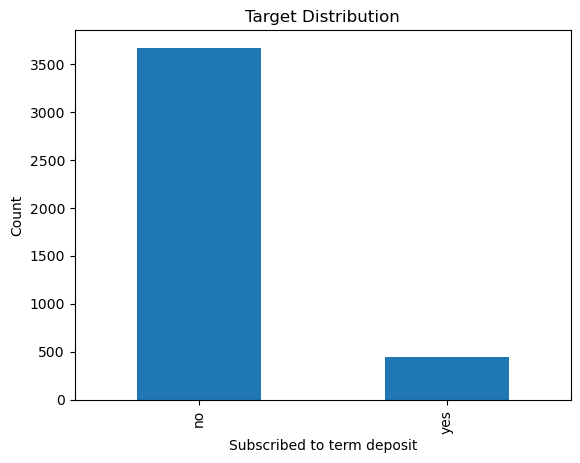

In [10]:

with zipfile.ZipFile("bank-additional.zip", "r") as zip_ref:
    zip_ref.extractall(".")

df = pd.read_csv("bank-additional/bank-additional.csv", sep=";")

display(df.head())
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))

print("\nSummary statistics:")
display(df.describe())

df["y"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Subscribed to term deposit")
plt.ylabel("Count")
plt.show()

### B

In [18]:

import pandas as pd
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("bank-additional/bank-additional.csv", sep=";")

df.replace("unknown", pd.NA, inplace=True)
df = df.dropna()
df = df.drop_duplicates()


df["y"] = df["y"].map({"no": 0, "yes": 1})


df = pd.get_dummies(df, drop_first=True)


scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols = numeric_cols.drop("y")  # don't scale target

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Preprocessed shape:", df.shape)
display(df.head())

Preprocessed shape: (3090, 48)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,-0.901967,0.862978,-0.196087,0.219471,-0.371557,-1.098486,-1.091213,-1.176100,-1.225445,-0.811284,...,True,False,False,False,False,False,False,False,True,False
1,-0.018084,0.328720,0.573810,0.219471,-0.371557,0.718536,0.788296,0.888937,0.775991,0.390498,...,True,False,False,False,False,False,False,False,True,False
2,-1.393012,-0.122178,-0.581036,0.219471,-0.371557,0.906504,1.592336,-0.248940,0.836452,0.875657,...,False,False,False,False,False,False,False,True,True,False
4,0.767588,-0.762530,-0.581036,0.219471,-0.371557,-0.033335,-0.567136,-0.291084,0.400792,0.453268,...,False,True,False,False,True,False,False,False,True,False
5,-0.705548,-0.497296,0.188862,0.219471,3.199551,-0.659895,1.138250,0.657147,-1.467855,-2.583226,...,False,False,False,True,False,True,False,False,False,False


### C

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop("y", axis=1)
y = df["y"]

categorical_cols = X.select_dtypes(include=["object", "bool"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
    ])
}

param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10]
    },
    
    "Decision Tree": {
        "classifier__max_depth": [3, 5, 10, None],
        "classifier__min_samples_split": [2, 5, 10]
    },
    
    "Random Forest": {
        "classifier__n_estimators": [50, 100],
        "classifier__max_depth": [5, 10, None],
        "classifier__min_samples_split": [2, 5]
    }
}

validation_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring="f1",
        n_jobs=1
    )
    
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_val_pred = best_model.predict(X_val)
    
    validation_results[name] = {
        "best_model": best_model,
        "best_params": grid.best_params_,
        "validation_accuracy": accuracy_score(y_val, y_val_pred),
        "validation_precision": precision_score(y_val, y_val_pred),
        "validation_recall": recall_score(y_val, y_val_pred),
        "validation_f1": f1_score(y_val, y_val_pred)
    }
    
    print("Best parameters:", grid.best_params_)
    print("Validation F1:", validation_results[name]["validation_f1"])


Training Logistic Regression...
Best parameters: {'classifier__C': 0.1}
Validation F1: 0.5871559633027523

Training Decision Tree...
Best parameters: {'classifier__max_depth': 3, 'classifier__min_samples_split': 2}
Validation F1: 0.5128205128205128

Training Random Forest...
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Validation F1: 0.55


### D

In [16]:

cv_results = {}

for name, result in validation_results.items():
    model = result["best_model"]
    
    scores = cross_val_score(
        model,
        X_train_full,
        y_train_full,
        cv=5,
        scoring="f1",
        n_jobs=1
    )
    
    cv_results[name] = {
        "validation_f1": result["validation_f1"],
        "cv_mean_f1": scores.mean(),
        "cv_std_f1": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T
display(cv_results_df)

print("""
Cross-validation is usually more reliable than a single train-validation split because it trains and evaluates the model on several different splits of the data.
This gives a more stable estimate of performance. The better method is the one with the stronger and more stable F1 score.
""")

,validation_f1,cv_mean_f1,cv_std_f1
Logistic Regression,0.593750,0.576945,0.021444
Decision Tree,0.548872,0.534872,0.026443
Random Forest,0.584475,0.522796,0.046908



Cross-validation is usually more reliable than a single train-validation split because it trains and evaluates the model on several different splits of the data.
This gives a more stable estimate of performance. The better method is the one with the stronger and more stable F1 score.



### E

In [17]:


test_results = {}

for name, result in validation_results.items():
    model = result["best_model"]
    
    model.fit(X_train_full, y_train_full)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    test_results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{name}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

test_results_df = pd.DataFrame(test_results).T
display(test_results_df)

best_model_name = test_results_df["f1"].idxmax()
print("Best model based on F1 score:", best_model_name)


Logistic Regression
Confusion matrix:
[[648  86]
 [ 14  76]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       734
           1       0.47      0.84      0.60        90

    accuracy                           0.88       824
   macro avg       0.72      0.86      0.77       824
weighted avg       0.92      0.88      0.89       824


Decision Tree
Confusion matrix:
[[636  98]
 [ 15  75]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       734
           1       0.43      0.83      0.57        90

    accuracy                           0.86       824
   macro avg       0.71      0.85      0.74       824
weighted avg       0.92      0.86      0.88       824


Random Forest
Confusion matrix:
[[665  69]
 [ 27  63]]

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93  

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.878641,0.469136,0.844444,0.603175,0.943097
Decision Tree,0.862864,0.433526,0.833333,0.570342,0.875840
Random Forest,0.883495,0.477273,0.700000,0.567568,0.933924


Best model based on F1 score: Logistic Regression


This is a classification task because the target variable `y` has two possible classes: whether the customer subscribed to a term deposit or not.

The best model was selected based mainly on F1 score, because the dataset is imbalanced and accuracy alone can be misleading. Cross-validation gives a more reliable estimate than a single validation split because it evaluates the model across several different train-test partitions. The final best model is the one with the strongest balance between precision and recall on the test set.